In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from  sklearn.metrics import r2_score

In [2]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

In [3]:
6 * np.random.rand(200,1) -3

array([[ 2.33399781],
       [-2.31587122],
       [ 0.96745048],
       [-1.07139714],
       [-0.87868837],
       [-0.61468595],
       [ 2.96946345],
       [-0.44582801],
       [ 2.44964891],
       [-2.82746234],
       [ 1.69115191],
       [ 0.73527361],
       [ 0.30972419],
       [ 2.81738134],
       [ 2.25317473],
       [-0.85353906],
       [-2.16240926],
       [ 2.61715075],
       [ 1.16933076],
       [ 0.79305426],
       [-0.73596756],
       [ 1.14059895],
       [ 1.98032742],
       [ 2.62107517],
       [-1.30136328],
       [-0.58413068],
       [-0.88648699],
       [ 0.50165551],
       [-2.33934979],
       [ 0.27490695],
       [ 0.08018881],
       [-0.86377122],
       [-2.44620425],
       [-0.12353352],
       [ 2.9184601 ],
       [ 0.80686755],
       [ 0.42326635],
       [-0.1855971 ],
       [-1.24073135],
       [ 2.95953114],
       [-2.87451922],
       [ 0.48434709],
       [ 1.99499881],
       [-0.53680817],
       [-0.25167291],
       [-0

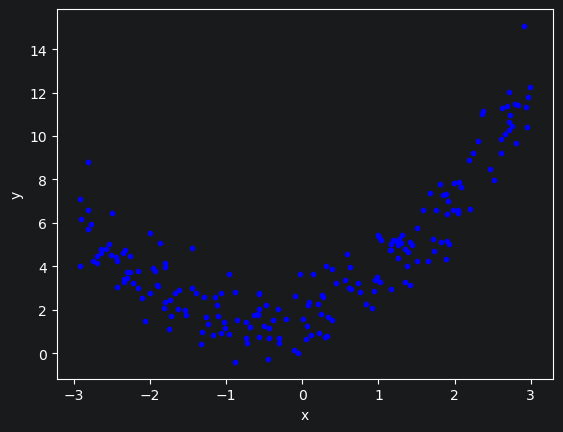

In [5]:
plt.plot(X,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.21875478705961982

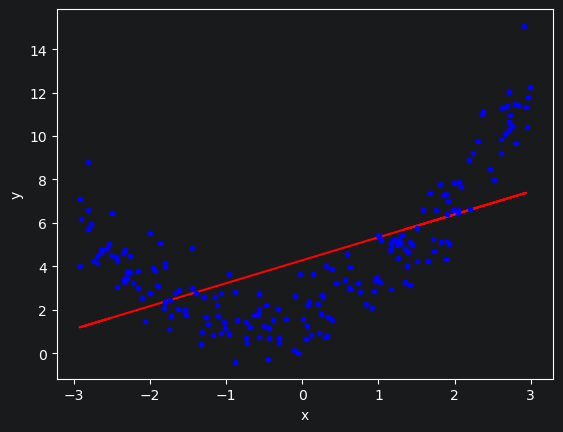

In [9]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Applying Polynomial linear Regression
### Degree 2

In [10]:
poly = PolynomialFeatures(degree = 2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [11]:
print(X_train[0])
print(X_train_trans[0])

[1.3538779]
[1.         1.3538779  1.83298538]


Include_bias parameter
`poly = PolynomialFeatures(degree = 2, include_bias = False)`

In [12]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test, y_pred)

0.8047688870815508

In [14]:
print(lr.coef_)
print(lr.intercept_)

[[0.         1.05362776 0.83980582]]
[1.80066759]


In [15]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

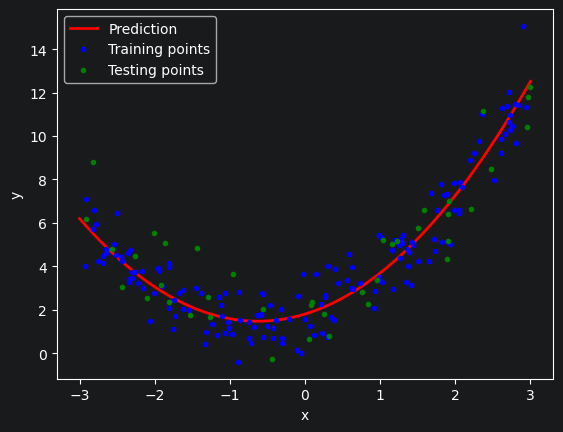

In [16]:
plt.plot(X_new,y_new,'r-', linewidth=2,label='Prediction')
plt.plot(X_train,y_train,'b.',label='Training points')
plt.plot(X_test,y_test,'g.',label='Testing points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Implement `Polynomial_Regression` class from scratch

In [17]:
import numpy as np
from itertools import combinations_with_replacement

class PolynomialRegression:

    def __init__(self, degree=2):
        self.degree = degree
        self.coef_ = None   # theta

    # 🔹 Step 1: Polynomial Feature Generator
    def _poly_features(self, X):
        n_samples, n_features = X.shape

        features = [np.ones(n_samples)]  # bias column

        for d in range(1, self.degree + 1):
            for comb in combinations_with_replacement(range(n_features), d):
                feature = np.ones(n_samples)
                for i in comb:
                    feature *= X[:, i]
                features.append(feature)

        return np.column_stack(features)

    # 🔹 Step 2: Fit using Normal Equation
    def fit(self, X, y):
        X_poly = self._poly_features(X)

        # Normal equation
        self.coef_ = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y

    # 🔹 Step 3: Prediction
    def predict(self, X):
        X_poly = self._poly_features(X)
        return X_poly @ self.coef_

In [18]:
# Sample data
X = np.array([[2, 3],
              [4, 5],
              [6, 7]])
y = np.array([10, 20, 30])

model = PolynomialRegression(degree=2)
model.fit(X, y)

y_pred = model.predict(X)

print("Coefficients:", model.coef_)
print("Predictions:", y_pred)

Coefficients: [-6.64748325e+14 -6.64748325e+14  6.64748325e+14 -2.96875000e+01
  1.45312500e+01  2.12500000e+01]
Predictions: [  95.5  -84.5 -216. ]
